#LAB 04: HISTOGRAM, HISTOGRAM EQUALIZATION MATCHING, AHE

In [12]:
# EV
import cv2
import numpy as np
import matplotlib.pyplot as plt
print("OpenCV:", cv2.__version__)
print("NumPy :", np.__version__)

# ChuanBiAnh
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/LaiBaTrung/XyLyAnh/refs/heads/main/LAB04_Images/source.png", "image.jpg")

OpenCV: 5.0.0
NumPy : 2.1.3


('image.jpg', <http.client.HTTPMessage at 0x7b82938755a0>)

# BÀI 1: HIS, PDF, CDF trên array

  r |  hist |      PDF |      CDF
  0 |     3 |   0.1875 |   0.1875
  1 |     4 |   0.2500 |   0.4375
  2 |     6 |   0.3750 |   0.8125
  3 |     3 |   0.1875 |   1.0000

sum(hist) = 16 (kỳ vọng = 16 )
sum(pdf)  = 1.0 (kỳ vọng ≈ 1)
cdf[-1]   = 1.0 (kỳ vọng ≈ 1)


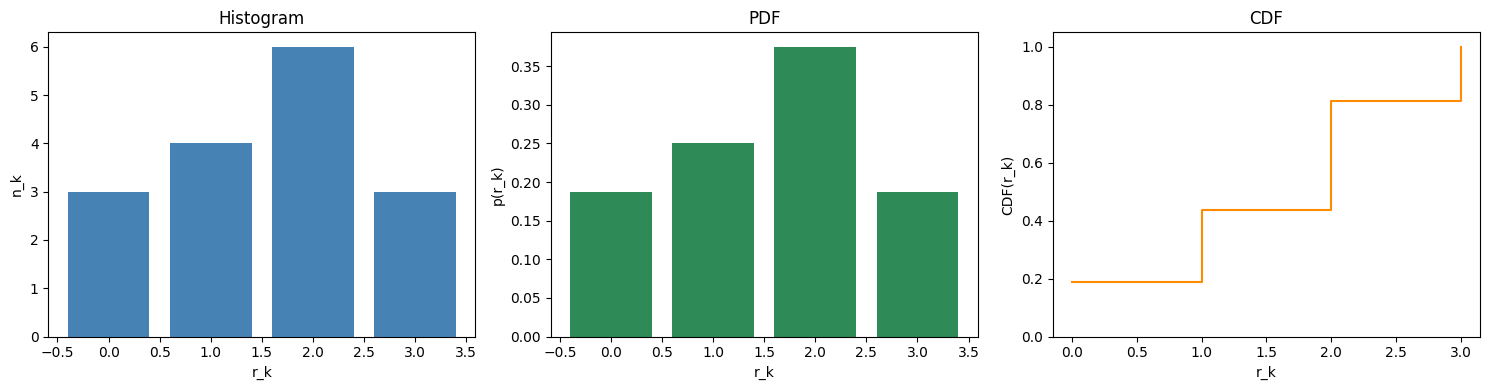

In [11]:
A = np.array([
    [0, 0, 1, 1],
    [0, 1, 2, 2],
    [1, 2, 2, 3],
    [2, 2, 3, 3]
], dtype=np.uint8)
L = 4

def hist_pdf_cdf(gray, levels=256):
    # TODO 1: histogram bằng np.bincount
    hist = np.bincount(gray.flatten(), minlength=levels).astype(np.int64)

    # TODO 2: PDF = hist / số pixel
    N = gray.size
    pdf = hist / N

    # TODO 3: CDF = cumulative sum
    cdf = np.cumsum(pdf)

    return hist, pdf, cdf

hist, pdf, cdf = hist_pdf_cdf(A, levels=L)

# TODO 4: in bảng r | hist | PDF | CDF
print(f"{'r':>3} | {'hist':>5} | {'PDF':>8} | {'CDF':>8}")
for r in range(L):
    print(f"{r:>3} | {hist[r]:>5} | {pdf[r]:>8.4f} | {cdf[r]:>8.4f}")

# TODO 5: kiểm tra sum(hist), sum(pdf), cdf[-1]
print("\nsum(hist) =", hist.sum(), "(kỳ vọng =", A.size, ")")
print("sum(pdf)  =", pdf.sum(), "(kỳ vọng ≈ 1)")
print("cdf[-1]   =", cdf[-1], "(kỳ vọng ≈ 1)")

# TODO 6: vẽ Histogram, PDF và CDF
r = np.arange(L)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(r, hist, color='steelblue')
axes[0].set_title("Histogram")
axes[0].set_xlabel("r_k"); axes[0].set_ylabel("n_k")

axes[1].bar(r, pdf, color='seagreen')
axes[1].set_title("PDF")
axes[1].set_xlabel("r_k"); axes[1].set_ylabel("p(r_k)")

axes[2].step(r, cdf, where='post', color='darkorange')
axes[2].set_title("CDF")
axes[2].set_xlabel("r_k"); axes[2].set_ylabel("CDF(r_k)")
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Trả lời Yêu cầu
- Histogram lưu/không lưu thông tin gì? Histogram lưu số lượng pixel ứng với mỗi mức xám (tần suất xuất hiện), nhưng không lưu vị trí (tọa độ) của các pixel đó trong ảnh — nhiều ảnh có bố cục khác nhau vẫn có thể cho cùng histogram.
- Vì sao CDF luôn không giảm? Vì CDF(r_k) = tổng cộng dồn của PDF (các giá trị p(r_j) ≥ 0), mỗi bước cộng thêm một giá trị ≥ 0 nên CDF chỉ có thể giữ nguyên hoặc tăng, không bao giờ giảm.
- Ảnh khác cấu trúc có thể cùng histogram? Có. Ví dụ: đảo vị trí (hoán vị) các pixel trong ma trận A mà không đổi giá trị của chúng sẽ cho ảnh khác về cấu trúc/không gian nhưng histogram (và PDF, CDF) hoàn toàn giống nhau, vì histogram không quan tâm vị trí pixel.

# BÀI 2: HISTOGRAM và thống kế trên ảnh thật

Thuộc tính      | Giá trị
------------------------------
Shape           | (512, 512)
Dtype           | uint8
Min             | 0
Max             | 255
Mean            | 112.1696
Std             | 13.3303
Dynamic range   | 255


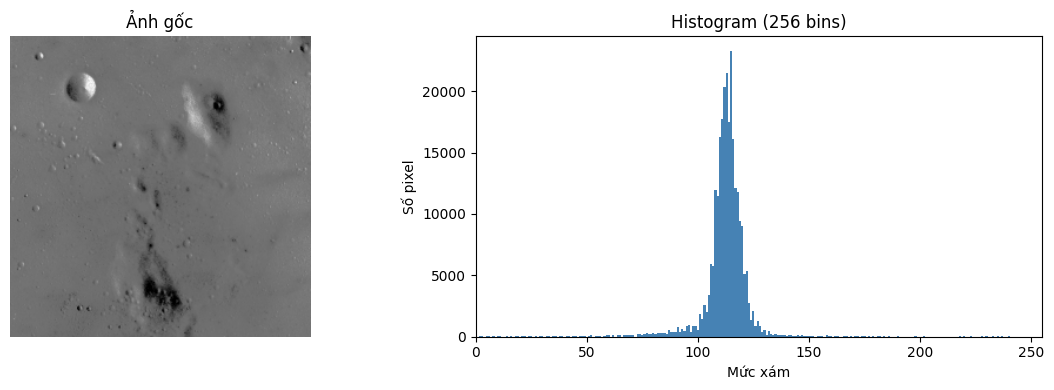

In [14]:
img = cv2.imread("image.jpg", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError("Không đọc được ảnh")

# TODO: tính min, max, mean, std, dynamic range
h, w = img.shape
shape = img.shape
dtype = img.dtype
min_val = img.min()
max_val = img.max()
mean_val = img.mean()
std_val = img.std()
dynamic_range = int(max_val) - int(min_val)

# Bảng thống kê
print(f"{'Thuộc tính':<15} | {'Giá trị'}")
print("-" * 30)
print(f"{'Shape':<15} | {shape}")
print(f"{'Dtype':<15} | {dtype}")
print(f"{'Min':<15} | {min_val}")
print(f"{'Max':<15} | {max_val}")
print(f"{'Mean':<15} | {mean_val:.4f}")
print(f"{'Std':<15} | {std_val:.4f}")
print(f"{'Dynamic range':<15} | {dynamic_range}")

# TODO: histogram 256 bins bằng np.bincount hoặc cv2.calcHist
hist = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()

# TODO: vẽ ảnh + histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Ảnh gốc")
axes[0].axis('off')

axes[1].bar(np.arange(256), hist, width=1, color='steelblue')
axes[1].set_title("Histogram (256 bins)")
axes[1].set_xlabel("Mức xám")
axes[1].set_ylabel("Số pixel")
axes[1].set_xlim(0, 255)

plt.tight_layout()
plt.show()



# Bài 3: HE 3 bit - tính tay và LUT

In [29]:
import pandas as pd
A3 = np.array([
    [0, 0, 1, 1],
    [1, 2, 2, 3],
    [3, 3, 4, 4],
    [6, 5, 6, 7]
], dtype=np.uint8)
L = 8

# TinhTay
tinhTay = pd.DataFrame({
    "r_k":         [0, 1, 2, 3, 4, 5, 6, 7],
    "hist":        [2, 3, 2, 3, 3, 1, 1, 1],
    "PDF":         [0.1250, 0.1875, 0.1250, 0.1875, 0.1875, 0.0625, 0.0625, 0.0625],
    "CDF":         [0.1250, 0.3125, 0.4375, 0.6250, 0.8125, 0.8750, 0.9375, 1.0000],
    "7xCDF":       [0.875, 2.1875, 3.0625, 4.375, 5.6875, 6.125, 6.5625, 7.000],
    "s_k (round)": [1, 2, 3, 4, 6, 6, 7, 7]
})


def he_3bit(gray, levels=8):
    L = levels

    # TODO: histogram
    hist = np.bincount(gray.flatten(), minlength=L)

    # TODO: PDF
    pdf = hist / gray.size

    # TODO: CDF
    cdf = np.cumsum(pdf)

    # TODO: (L-1) x CDF -> round -> LUT
    lut = np.round((L - 1) * cdf).astype(np.uint8)

    # TODO: áp LUT lên ảnh gốc
    output = lut[gray]

    return hist, pdf, cdf, lut, output

hist, pdf, cdf, lut, output = he_3bit(A3, levels=L)


print("\nLUT r->s:", dict(enumerate(lut)))
print("\nMa trận output sau HE:\n", output)

tinhTay




LUT r->s: {0: np.uint8(1), 1: np.uint8(2), 2: np.uint8(3), 3: np.uint8(4), 4: np.uint8(5), 5: np.uint8(6), 6: np.uint8(7), 7: np.uint8(7)}

Ma trận output sau HE:
 [[1 1 2 2]
 [2 3 3 4]
 [4 4 5 5]
 [7 6 7 7]]


,r_k,hist,PDF,CDF,7xCDF,s_k (round)
0,0,2,0.1250,0.1250,0.8750,1
1,1,3,0.1875,0.3125,2.1875,2
2,2,2,0.1250,0.4375,3.0625,3
3,3,3,0.1875,0.6250,4.3750,4
4,4,3,0.1875,0.8125,5.6875,6
5,5,1,0.0625,0.8750,6.1250,6
6,6,1,0.0625,0.9375,6.5625,7
7,7,1,0.0625,1.0000,7.0000,7


# Giải thích vì sao nhiều mức input có thể cùng ánh xạ về một mức output:
- Vì công thức s_k = round((L-1) × CDF(r_k)) chỉ phụ thuộc vào giá trị CDF tại từng mức xám, mà CDF là hàm không giảm và tăng theo từng bước nhỏ (bằng PDF của mức đó). Khi PDF của một mức xám nhỏ (số pixel ít), CDF tăng rất ít giữa hai mức liên tiếp, khiến (L-1)×CDF của hai mức r khác nhau rơi vào cùng một khoảng và sau khi round cho ra cùng một giá trị s.
- Đây chính là hiện tượng mất thông tin (information loss) đặc trưng của HE khi số mức xám output (L) nhỏ hơn số mức input hoặc phân bố input không đều — ví dụ ở đây r=4 và r=5 cùng ánh xạ về s=6.

# Bài 4: HE 8-bit - Tự cài và đối chứng OpenCV

Max absolute difference (manual vs OpenCV): 0


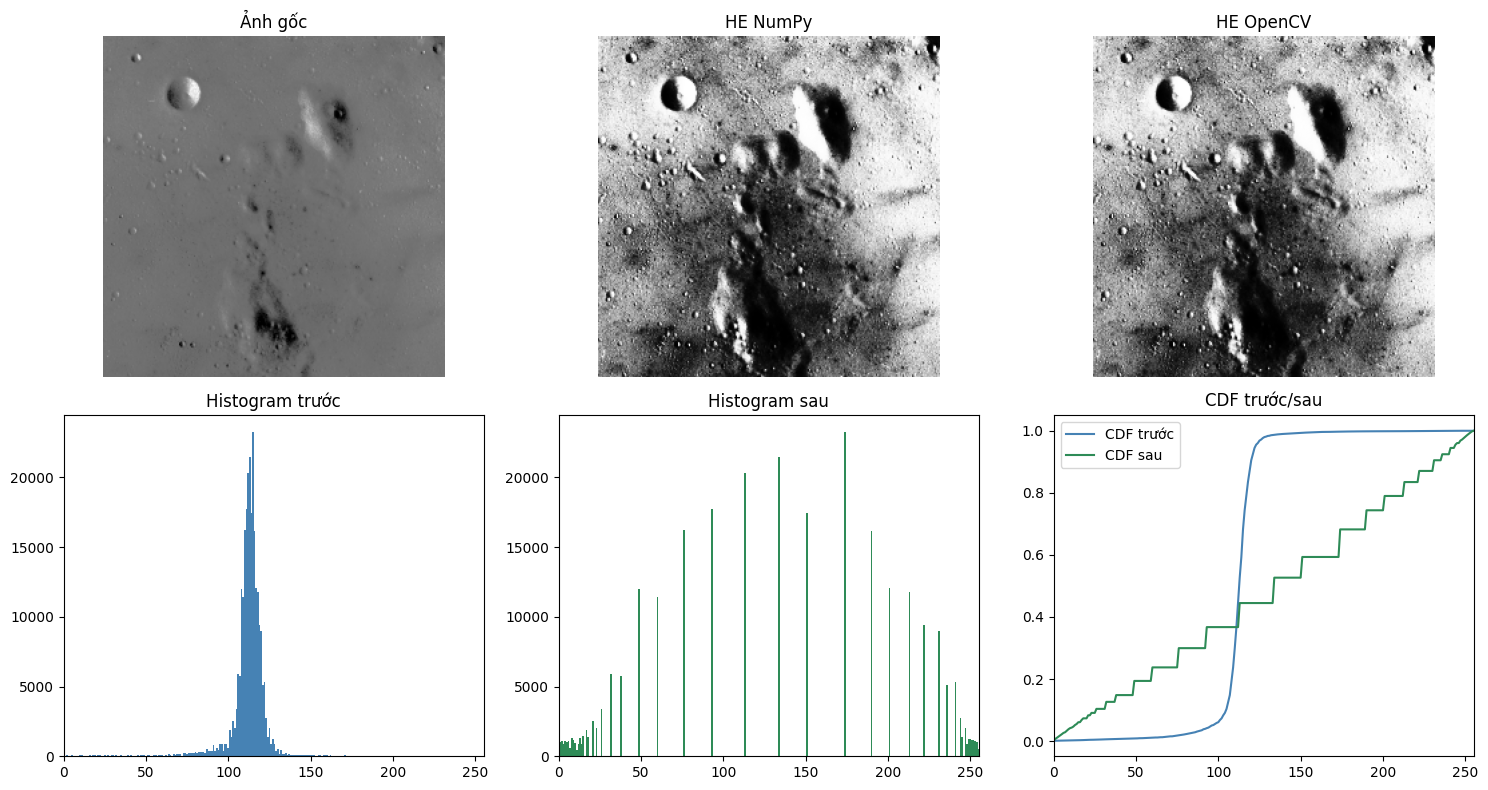


Bảng min/max/mean/std:
         Ảnh  min  max        mean        std
0   Original    0  255  112.169571  13.330291
1   HE NumPy    0  255  133.758972  74.013985
2  HE OpenCV    0  255  133.758972  74.013985

Giá trị max absolute difference giữa HE tự cài và OpenCV: 0


In [31]:
def he_numpy(gray):
    N = gray.size

    # TODO 1: histogram 256 bins
    hist = np.bincount(gray.flatten(), minlength=256)

    # TODO 2: cumulative count
    cdf_count = np.cumsum(hist)

    # TODO 3: tìm cdf_min khác 0 đầu tiên
    nonzero = cdf_count[cdf_count > 0]
    cdf_min = nonzero[0] if nonzero.size > 0 else 0

    # TODO 4: xử lý trường hợp ảnh hằng (N == cdf_min -> tránh chia 0)
    if N == cdf_min:
        lut = np.arange(256, dtype=np.uint8)
        out = lut[gray]
        return out, lut

    # TODO 5: LUT = (cdf_count-cdf_min)/(N-cdf_min)*255
    lut = (cdf_count.astype(np.float64) - cdf_min) / (N - cdf_min) * 255

    # TODO 6: clip + round/cast uint8
    lut = np.clip(np.round(lut), 0, 255).astype(np.uint8)

    # TODO 7: output = lut[gray]
    out = lut[gray]

    return out, lut

he_manual, lut = he_numpy(img)
he_cv = cv2.equalizeHist(img)

# TODO 8: max absolute difference manual/OpenCV
diff = np.abs(he_manual.astype(int) - he_cv.astype(int))
max_diff = diff.max()
print("Max absolute difference (manual vs OpenCV):", max_diff)

# TODO 9: histogram/CDF trước và sau
hist_before = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
cdf_before = np.cumsum(hist_before) / img.size

hist_after = cv2.calcHist([he_manual], [0], None, [256], [0, 256]).flatten()
cdf_after = np.cumsum(hist_after) / he_manual.size

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0,0].imshow(img, cmap='gray', vmin=0, vmax=255); axes[0,0].set_title("Ảnh gốc"); axes[0,0].axis('off')
axes[0,1].imshow(he_manual, cmap='gray', vmin=0, vmax=255); axes[0,1].set_title("HE NumPy"); axes[0,1].axis('off')
axes[0,2].imshow(he_cv, cmap='gray', vmin=0, vmax=255); axes[0,2].set_title("HE OpenCV"); axes[0,2].axis('off')

axes[1,0].bar(np.arange(256), hist_before, width=1, color='steelblue')
axes[1,0].set_title("Histogram trước"); axes[1,0].set_xlim(0,255)

axes[1,1].bar(np.arange(256), hist_after, width=1, color='seagreen')
axes[1,1].set_title("Histogram sau"); axes[1,1].set_xlim(0,255)

axes[1,2].plot(cdf_before, label='CDF trước', color='steelblue')
axes[1,2].plot(cdf_after, label='CDF sau', color='seagreen')
axes[1,2].set_title("CDF trước/sau"); axes[1,2].legend(); axes[1,2].set_xlim(0,255)

plt.tight_layout()
plt.show()

# TODO 10: bảng thống kê
stats = pd.DataFrame({
    "Ảnh": ["Original", "HE NumPy", "HE OpenCV"],
    "min": [img.min(), he_manual.min(), he_cv.min()],
    "max": [img.max(), he_manual.max(), he_cv.max()],
    "mean": [img.mean(), he_manual.mean(), he_cv.mean()],
    "std": [img.std(), he_manual.std(), he_cv.std()]
})
print("\nBảng min/max/mean/std:")
print(stats)

print("\nGiá trị max absolute difference giữa HE tự cài và OpenCV:", max_diff)

# Trả lời Yêu cầu:
- HE cải thiện global contrast trong trường hợp nào?

=> Khi ảnh gốc có histogram co cụm trong một dải hẹp mức xám (contrast thấp, ví dụ ảnh thiên tối hoặc thiên sáng đều), HE sẽ kéo giãn CDF để phân bố lại mức xám đều hơn trên toàn dải [0,255], làm ảnh rõ nét/tương phản hơn. Với ảnh đã có contrast cao/histogram trải đều sẵn thì HE cải thiện rất ít.
- Vì sao histogram sau HE không nhất thiết phẳng hoàn toàn?

=> Vì phép biến đổi HE hoạt động trên các giá trị mức xám rời rạc, không phải liên tục — nhiều mức input có thể gộp vào cùng một mức output (do làm tròn), khiến hist sau HE vẫn có các cột cao thấp không đều (chỉ có CDF được kéo gần tuyến tính, còn hist chỉ xấp xỉ đều chứ không hoàn toàn phẳng).
- Vì sao công thức 255×CDF có thể khác kết quả cv2.equalizeHist() dùng CDF_min?

=> Vì cv2.equalizeHist chuẩn hoá theo công thức (cdf - cdf_min)/(N - cdf_min) × 255, loại trừ cdf_min ra khỏi phép chia để đảm bảo mức xám nhỏ nhất trong ảnh luôn ánh xạ về đúng 0, còn công thức đơn giản 255×CDF không trừ cdf_min nên mức xám nhỏ nhất có thể không map về 0 — dẫn đến kết quả lệch nhau, đặc biệt khi cdf_min lớn.
- Ảnh nào mà HE làm noise hoặc vùng sáng/tối trở nên xấu hơn?

=>Ảnh có nhiễu nền hoặc vùng lớn gần như đồng nhất (ví dụ bầu trời, nền phẳng)— HE khuếch đại chênh lệch nhỏ giữa các mức xám gần nhau trong vùng đó (vì tần suất pixel cao ở đó khiến CDF dốc), làm lộ rõ nhiễu hạt (noise) hoặc tạo hiệu ứng "banding"/giả tạo ở vùng sáng/tối đồng nhất vốn trước đó mượt mà.

# Bài 5: Matching bằng CDF và LUT

Bảng khoảng cách |CDF_T - CDF_S|:
                  z=0 (CDF_T=0.1)  z=1 (CDF_T=0.45)  z=2 (CDF_T=0.7)  \
r=0 (CDF_S=0.15)             0.05              0.30             0.55   
r=1 (CDF_S=0.4)              0.30              0.05             0.30   
r=2 (CDF_S=0.75)             0.65              0.30             0.05   
r=3 (CDF_S=1.0)              0.90              0.55             0.30   

                  z=3 (CDF_T=1.0)  
r=0 (CDF_S=0.15)             0.85  
r=1 (CDF_S=0.4)              0.60  
r=2 (CDF_S=0.75)             0.25  
r=3 (CDF_S=1.0)              0.00  

LUT source->target: {0: np.uint8(0), 1: np.uint8(1), 2: np.uint8(2), 3: np.uint8(3)}

Matched (tính tay):
 [[0 1 2]
 [2 3 3]]


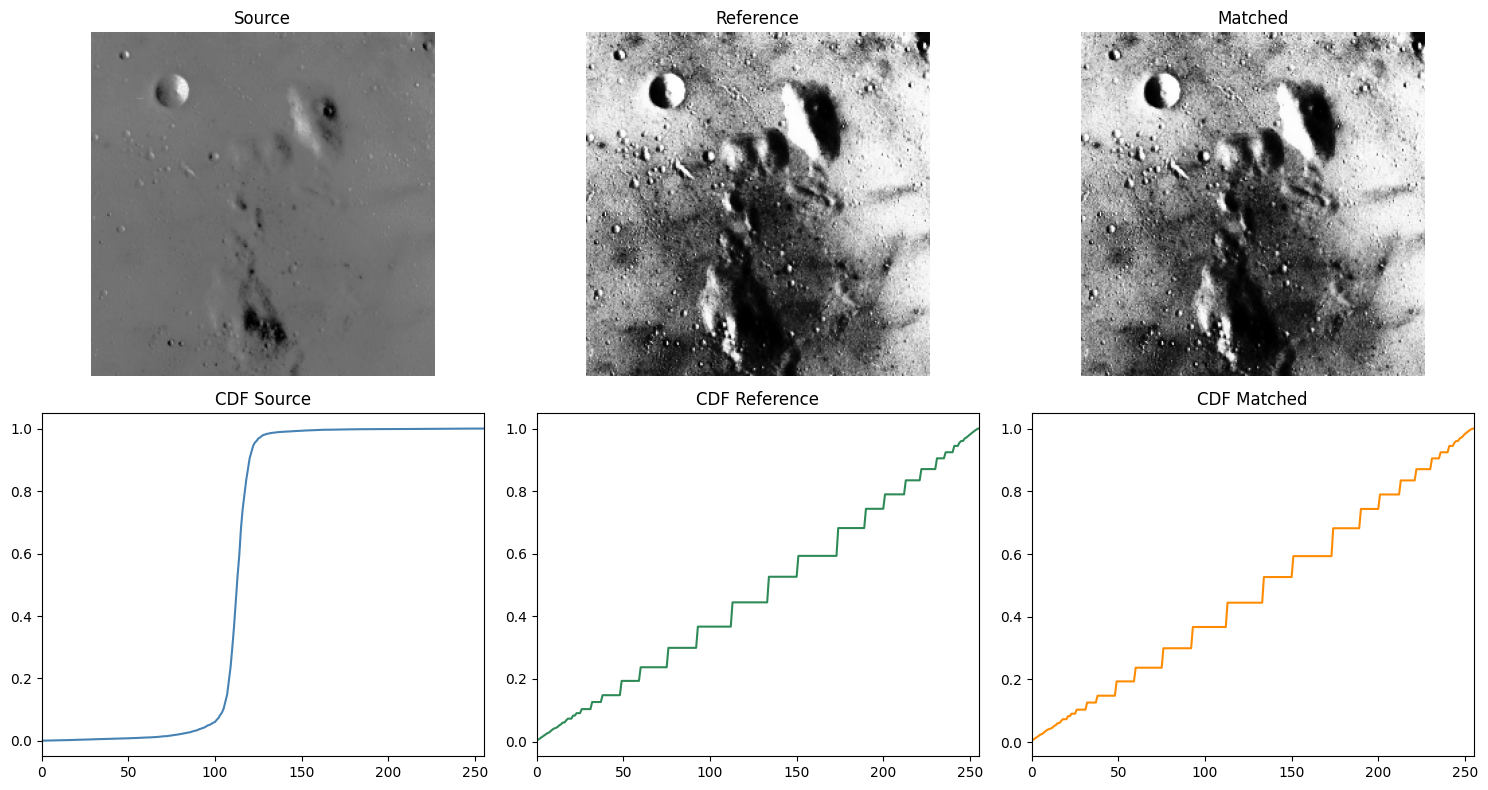

In [35]:
def histogram_matching(source, reference):
    N_s = source.size
    N_r = reference.size

    # TODO 1: histogram 256 bins source/reference
    hs = np.bincount(source.flatten(), minlength=256)
    ht = np.bincount(reference.flatten(), minlength=256)

    # TODO 2: CDF chuẩn hóa
    cs = np.cumsum(hs) / N_s
    ct = np.cumsum(ht) / N_r

    # TODO 3: xây LUT
    lut = np.zeros(256, dtype=np.uint8)
    for r in range(256):
        # z = argmin |ct - cs[r]|
        z = np.argmin(np.abs(ct - cs[r]))
        lut[r] = z

    # TODO 4: áp LUT
    matched = lut[source]

    return matched, lut, cs, ct


Source = np.array([[0,1,2],
                    [2,3,3]], dtype=np.uint8)

L_small = 4
cs_hand = np.array([0.15, 0.40, 0.75, 1.00])
ct_hand = np.array([0.10, 0.45, 0.70, 1.00])

lut_hand = np.zeros(L_small, dtype=np.uint8)
dist_table = np.zeros((L_small, L_small))
for r in range(L_small):
    for z in range(L_small):
        dist_table[r, z] = abs(ct_hand[z] - cs_hand[r])
    lut_hand[r] = np.argmin(dist_table[r])

df_dist = pd.DataFrame(dist_table,
                        index=[f"r={r} (CDF_S={cs_hand[r]})" for r in range(L_small)],
                        columns=[f"z={z} (CDF_T={ct_hand[z]})" for z in range(L_small)])
print("Bảng khoảng cách |CDF_T - CDF_S|:")
print(df_dist)
print("\nLUT source->target:", dict(enumerate(lut_hand)))

matched_hand = lut_hand[Source]
print("\nMatched (tính tay):\n", matched_hand)


reference = he_cv
matched, lut_img, cs_img, ct_img = histogram_matching(img, reference)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0,0].imshow(img, cmap='gray', vmin=0, vmax=255); axes[0,0].set_title("Source"); axes[0,0].axis('off')
axes[0,1].imshow(reference, cmap='gray', vmin=0, vmax=255); axes[0,1].set_title("Reference"); axes[0,1].axis('off')
axes[0,2].imshow(matched, cmap='gray', vmin=0, vmax=255); axes[0,2].set_title("Matched"); axes[0,2].axis('off')

axes[1,0].plot(cs_img, color='steelblue'); axes[1,0].set_title("CDF Source"); axes[1,0].set_xlim(0,255)
axes[1,1].plot(ct_img, color='seagreen'); axes[1,1].set_title("CDF Reference"); axes[1,1].set_xlim(0,255)

cdf_matched = np.cumsum(cv2.calcHist([matched],[0],None,[256],[0,256]).flatten())/matched.size
axes[1,2].plot(cdf_matched, color='darkorange'); axes[1,2].set_title("CDF Matched"); axes[1,2].set_xlim(0,255)

plt.tight_layout()
plt.show()

# Nhận xét:
- Bảng khoảng cách CDF: với mỗi r, giá trị z được chọn là z sao cho CDF_T(z) gần CDF_S(r) nhất (khoảng cách nhỏ nhất trong hàng tương ứng của bảng). Trong ví dụ nhỏ, do CDF_source và CDF_target khá tương đồng nhau (cùng dạng tăng), LUT thu được là ánh xạ đồng nhất (0→0, 1→1, 2→2, 3→3).
- Matched có tiến gần reference hay không? Có — sau khi matching, CDF của ảnh Matched sẽ xấp xỉ (không nhất thiết trùng tuyệt đối, do rời rạc hoá mức xám) với CDF của ảnh Reference, khác với CDF của Source ban đầu; nghĩa là phân bố cường độ của ảnh Matched được "kéo" về gần giống phân bố cường độ mong muốn (Reference), thay vì chỉ trải đều như HE thông thường.

# Bài 6: Đánh giá histogram matching bằng metric

In [36]:
def normalized_hist(gray):
    h = cv2.calcHist([gray], [0], None, [256], [0, 256])
    h = cv2.normalize(h, None, alpha=1.0, norm_type=cv2.NORM_L1)
    return h

# TODO: tính Correlation, Chi-square, Intersection, Bhattacharyya
# cho Source-Reference và Matched-Reference

h_source = normalized_hist(img)
h_reference = normalized_hist(reference)
h_matched = normalized_hist(matched)

metrics_names = ["Correlation", "Chi-square", "Intersection", "Bhattacharyya"]
metrics_cv = [cv2.HISTCMP_CORREL, cv2.HISTCMP_CHISQR,
              cv2.HISTCMP_INTERSECT, cv2.HISTCMP_BHATTACHARYYA]

src_ref = [cv2.compareHist(h_source, h_reference, m) for m in metrics_cv]
matched_ref = [cv2.compareHist(h_matched, h_reference, m) for m in metrics_cv]

df_metrics = pd.DataFrame({
    "Metric": metrics_names,
    "Source-Reference": src_ref,
    "Matched-Reference": matched_ref
})

print(df_metrics)

          Metric  Source-Reference  Matched-Reference
0    Correlation          0.059734           0.999774
1     Chi-square        203.263616           0.006377
2   Intersection          0.086349           0.992661
3  Bhattacharyya          0.925320           0.027707


# Trả lời Yêu cầu:
- Metric nào càng lớn thì tốt? Metric nào càng nhỏ thì tốt?

    => Correlation và Intersection: càng lớn (gần 1) thì hai histogram càng giống nhau → càng tốt.
    Chi-square và Bhattacharyya: càng nhỏ (gần 0) thì hai histogram càng giống nhau → càng tốt.
    Kỳ vọng: Matched-Reference phải có Correlation/Intersection cao hơn và Chi-square/Bhattacharyya thấp hơn so với Source-Reference, chứng tỏ matching đã kéo phân bố Source gần Reference hơn.
- Vì sao các metric histogram có thể cho thứ hạng khác nhau?

    => Vì mỗi metric đo "độ giống nhau" theo cách toán học khác nhau: Correlation nhạy với hình dạng tương quan tuyến tính giữa hai phân bố, Chi-square nhấn mạnh sai khác tương đối tại các bin có tần suất nhỏ (dễ bị khuếch đại), Intersection chỉ lấy phần chồng lấp tối thiểu giữa hai histogram tại từng bin, còn Bhattacharyya đo khoảng cách theo độ chồng lấp xác suất (căn bậc hai tích các bin). Do công thức và độ nhạy khác nhau với các bin có giá trị lớn/nhỏ/bằng 0, hai ảnh có thể được đánh giá "giống" theo metric này nhưng "khác" theo metric khác.

- Reference không phù hợp có thể làm tone ảnh matched kém tự nhiên như thế nào?
    => Nếu Reference có phân bố cường độ rất khác biệt về đặc tính (ví dụ ảnh chụp điều kiện sáng hoàn toàn khác, nội dung cảnh khác hẳn, hoặc bị cháy sáng/quá tối), thì histogram matching sẽ ép CDF của Source phải khớp với CDF Reference đó, dẫn đến ảnh Matched có thể bị lệch tone màu (quá sáng/quá tối không đúng thực tế cảnh gốc), mất chi tiết ở vùng bóng đổ hoặc vùng sáng (do bị nén/kéo giãn dải xám không phù hợp với nội dung ảnh gốc), hoặc xuất hiện hiện tượng banding/posterization ở vùng có ít mức xám tương ứng — khiến ảnh trông giả tạo, không tự nhiên so với bản chất ảnh Source ban đầu.


# Bài 7: AHE theo tile - Minh họa

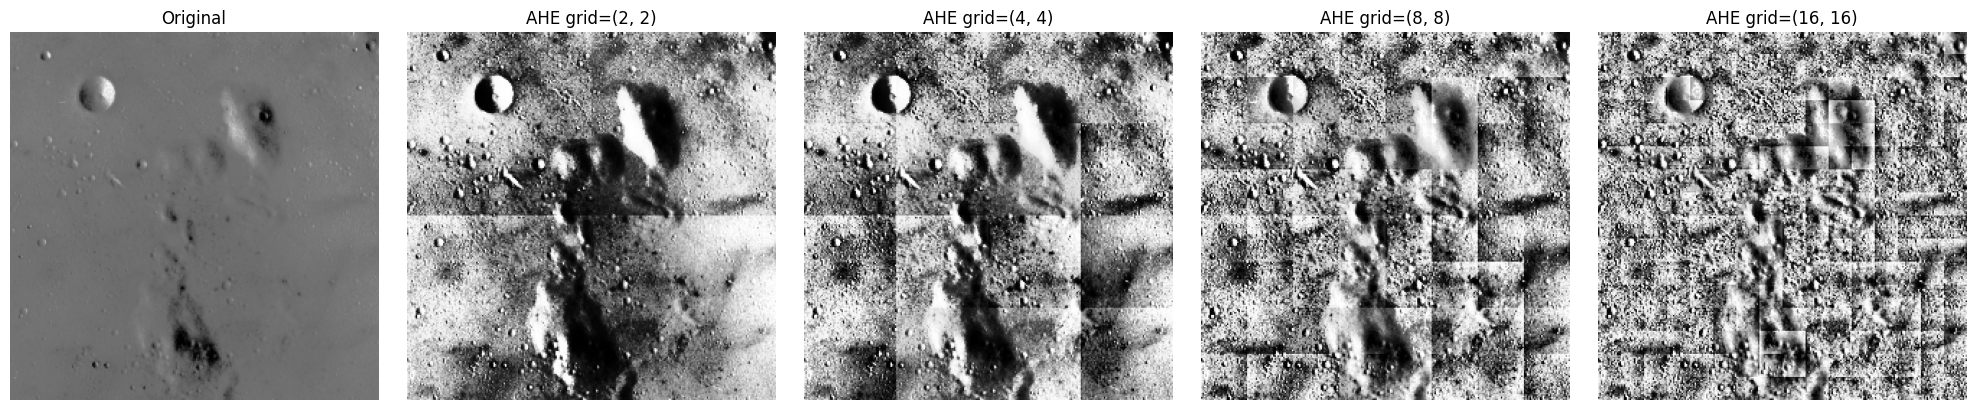

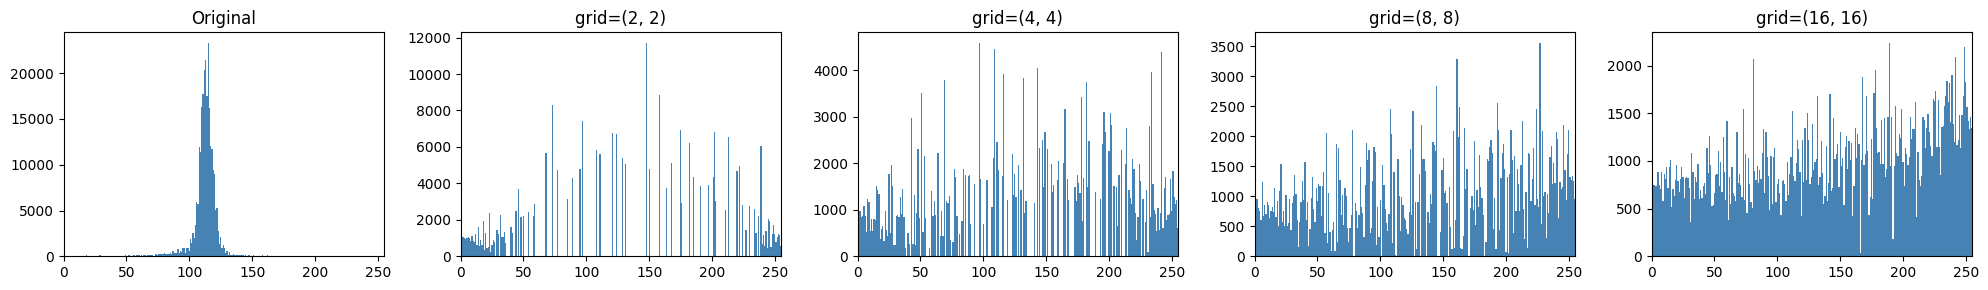

             Ảnh  min  max        mean        std
0       Original    0  255  112.169571  13.330291
1    grid=(2, 2)    0  255  135.065628  74.151087
2    grid=(4, 4)    0  255  137.129929  74.316509
3    grid=(8, 8)    0  255  139.998734  74.358491
4  grid=(16, 16)    0  255  142.352554  74.678039


In [37]:
def ahe_tiles_demo(gray, grid=(8,8)):
    H, W = gray.shape
    gy, gx = grid

    # TODO 1: tạo biên tile bằng np.linspace
    y_edges = np.linspace(0, H, gy + 1, dtype=int)
    x_edges = np.linspace(0, W, gx + 1, dtype=int)

    out = np.zeros_like(gray)

    # TODO 2: duyệt từng tile
    for i in range(gy):
        for j in range(gx):
            y0, y1 = y_edges[i], y_edges[i+1]
            x0, x1 = x_edges[j], x_edges[j+1]
            tile = gray[y0:y1, x0:x1]

            # TODO 3: equalize từng tile bằng he_numpy(tile)
            eq_tile, _ = he_numpy(tile)

            # TODO 4: ghép tile trở lại output
            out[y0:y1, x0:x1] = eq_tile
    # Lưu ý: phiên bản này KHÔNG nội suy giữa tile

    return out


grids = [(2,2), (4,4), (8,8), (16,16)]
results = {g: ahe_tiles_demo(img, grid=g) for g in grids}


fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original"); axes[0].axis('off')

for ax, g in zip(axes[1:], grids):
    ax.imshow(results[g], cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"AHE grid={g}")
    ax.axis('off')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 5, figsize=(20, 3))
imgs_all = {"Original": img, **{f"grid={g}": results[g] for g in grids}}

for ax, (name, im) in zip(axes, imgs_all.items()):
    h = cv2.calcHist([im], [0], None, [256], [0, 256]).flatten()
    ax.bar(np.arange(256), h, width=1, color='steelblue')
    ax.set_title(name)
    ax.set_xlim(0, 255)

plt.tight_layout()
plt.show()


stats_rows = []
for name, im in imgs_all.items():
    stats_rows.append({
        "Ảnh": name,
        "min": im.min(),
        "max": im.max(),
        "mean": im.mean(),
        "std": im.std()
    })
df_stats = pd.DataFrame(stats_rows)
print(df_stats)

# Trả lời Yêu cầu:
- Vì sao tile nhỏ làm AHE thích nghi cục bộ mạnh hơn?

    => Tile càng nhỏ thì mỗi tile chỉ bao phủ một vùng ảnh có nội dung/độ sáng tương đối đồng nhất, nên histogram của tile phản ánh sát đặc điểm cục bộ (local) của vùng đó hơn là đặc điểm trung bình toàn ảnh. Do đó phép cân bằng histogram trong từng tile nhỏ sẽ khuếch đại chi tiết cục bộ mạnh hơn (thích nghi theo từng vùng nhỏ), thay vì áp dụng một phép biến đổi tổng quát như HE toàn ảnh.
- Vì sao AHE có thể khuếch đại noise ở vùng gần đồng nhất?

    => Ở vùng ảnh gần như đồng nhất (ví dụ nền phẳng, bầu trời), các giá trị pixel chỉ dao động rất nhỏ quanh một mức xám do nhiễu. Khi tile chỉ chứa dải giá trị hẹp này, CDF của tile rất dốc trong khoảng giá trị đó, nên phép ánh xạ HE sẽ kéo giãn mạnh sự khác biệt nhỏ (vốn chỉ là nhiễu) thành khoảng cách lớn trong ảnh output — khiến nhiễu trở nên rõ rệt, gây hiệu ứng lấm tấm (graininess) mà mắt thường có thể nhìn thấy.
- Vì sao equalize tile độc lập tạo đường biên?

    => Vì mỗi tile có phân bố (histogram, CDF) và do đó có LUT ánh xạ riêng biệt, không liên quan đến các tile lân cận. Hai pixel có giá trị gốc gần giống nhau nhưng nằm ở hai tile khác nhau (ngay sát ranh giới) có thể bị ánh xạ theo hai LUT hoàn toàn khác nhau, dẫn đến giá trị output chênh lệch đột ngột tại đúng đường biên tile — tạo ra artifact dạng lưới/đường seam nhìn thấy rõ trên ảnh kết quả. Đây chính là lý do CLAHE thực tế cần thêm bước nội suy song tuyến (bilinear interpolation) giữa các tile để làm mượt chuyển tiếp.

# Bài 8: Mô phỏng AHE khuếch đại Noise

In [38]:
T = np.array([
    [100,100,100],
    [100,101,100],
    [100,100,100]
], dtype=np.uint8)

# TODO: tính histogram/PDF/CDF của T
he_T, lut_T = he_numpy(T)

hist_T = np.bincount(T.flatten(), minlength=256)
pdf_T = hist_T / T.size
cdf_T = np.cumsum(pdf_T)
# TODO: equalize T và ghi mapping 100-> ?, 101->?
df_T = pd.DataFrame({
    "r": [100, 101],
    "hist": [hist_T[100], hist_T[101]],
    "PDF": [pdf_T[100], pdf_T[101]],
    "CDF": [cdf_T[100], cdf_T[101]],
    "s (LUT)": [lut_T[100], lut_T[101]]
})
print(df_T)

print("\nMa trận sau equalize:\n", he_T)

     r  hist       PDF       CDF  s (LUT)
0  100     8  0.888889  0.888889        0
1  101     1  0.111111  1.000000      255

Ma trận sau equalize:
 [[  0   0   0]
 [  0 255   0]
 [  0   0   0]]


# Giải thích:
- vì sao mức chênh lệch 1 ban đầu bị khuếch đại?

    => Trong công thức chuẩn hoá của cv2.equalizeHist: s = (cdf_count(r) - cdf_min)/(N - cdf_min) × 255, mẫu số (N - cdf_min) chính là tổng số pixel không thuộc mức xám nhỏ nhất (ở đây = 9 - 8 = 1). Vì chỉ có duy nhất 1 pixel (giá trị 101) nằm ngoài mức "nền" 100, toàn bộ khoảng động [0, 255] bị "dồn" để phân biệt riêng cho đúng 1 pixel này với phần còn lại. Kết quả là chênh lệch gốc chỉ 1 mức xám (100 vs 101) — vốn gần như không thể nhận ra bằng mắt thường — bị kéo giãn thành chênh lệch 255 mức xám (đen tuyệt đối vs trắng tuyệt đối) sau equaliz

# Bài 10. Histogram Enhancement Pipeline

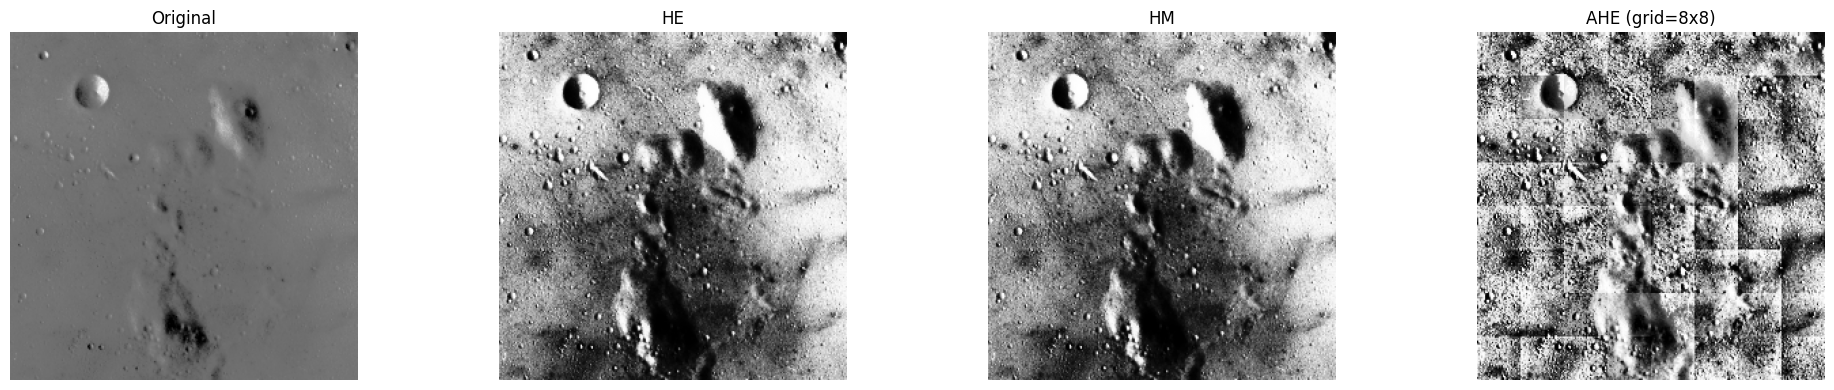

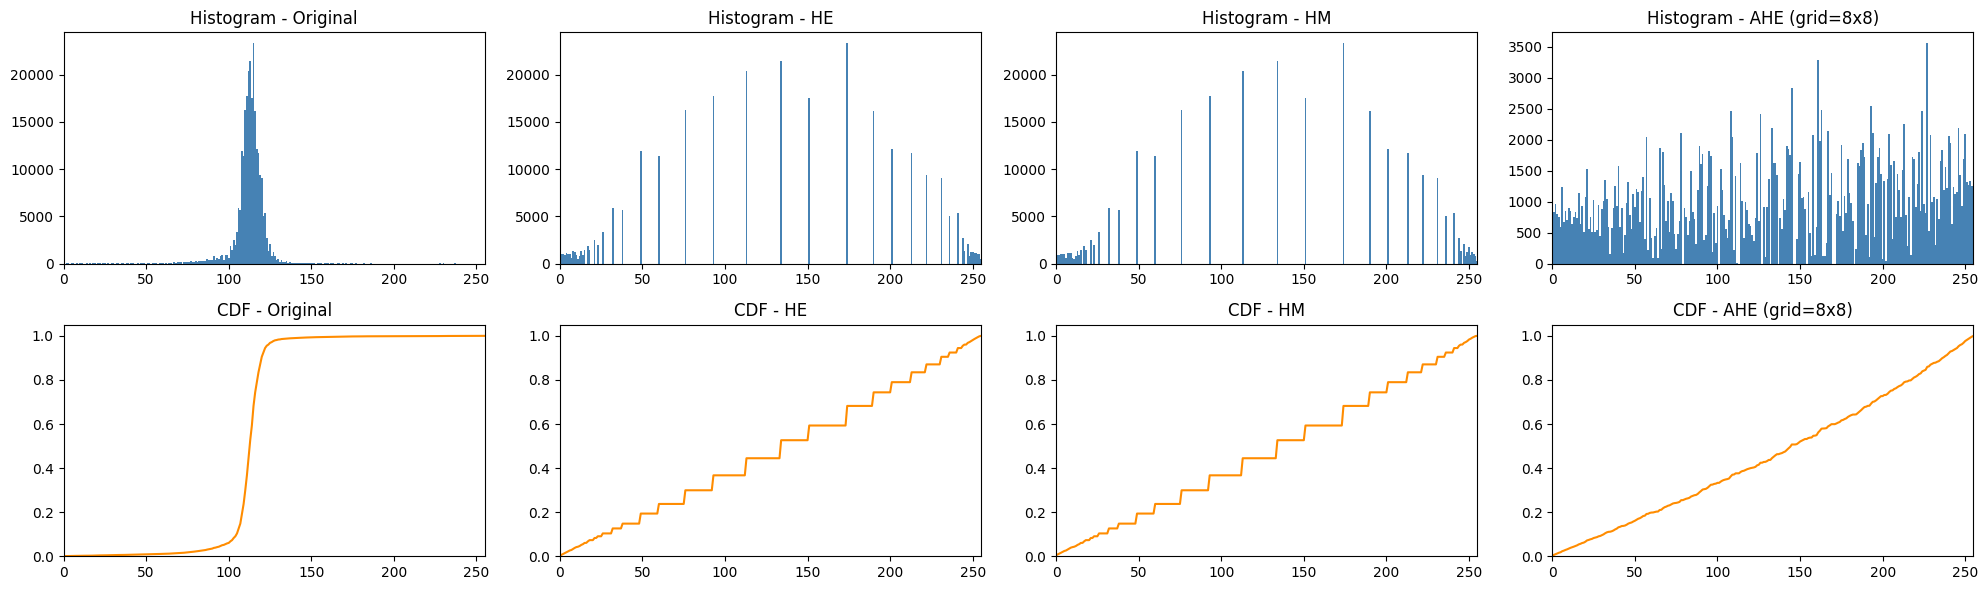

      Phương pháp  min  max    mean    std  dynamic range
0        Original    0  255  112.17  13.33            255
1              HE    0  255  133.76  74.01            255
2              HM    0  255  133.74  74.03            255
3  AHE (grid=8x8)    0  255  140.00  74.36            255
      Phương pháp  Correlation (vs Original)  Chi-square (vs Original)  \
0        Original                   1.000000                  0.000000   
1              HE                   0.059734                  0.905622   
2              HM                   0.059745                  0.905522   
3  AHE (grid=8x8)                  -0.076844                 92.346707   

   Intersection (vs Original)  Bhattacharyya (vs Original)  
0                    1.000000                     0.000000  
1                    0.086349                     0.925320  
2                    0.086349                     0.925318  
3                    0.157867                     0.773303  


In [39]:
methods = {
    "Original": img,
    "HE": he_manual,
    "HM": matched,
    "AHE (grid=8x8)": results[(8,8)]
}

# Hiển thị ảnh
fig, axes = plt.subplots(1, len(methods), figsize=(5*len(methods), 4))
for ax, (name, im) in zip(axes, methods.items()):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Histogram/CDF tương ứng
fig, axes = plt.subplots(2, len(methods), figsize=(5*len(methods), 6))
for col, (name, im) in enumerate(methods.items()):
    h = cv2.calcHist([im], [0], None, [256], [0, 256]).flatten()
    c = np.cumsum(h) / im.size

    axes[0, col].bar(np.arange(256), h, width=1, color='steelblue')
    axes[0, col].set_title(f"Histogram - {name}")
    axes[0, col].set_xlim(0, 255)

    axes[1, col].plot(c, color='darkorange')
    axes[1, col].set_title(f"CDF - {name}")
    axes[1, col].set_xlim(0, 255)
    axes[1, col].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Bảng thống kê
stats_rows = []
for name, im in methods.items():
    stats_rows.append({
        "Phương pháp": name,
        "min": im.min(),
        "max": im.max(),
        "mean": round(im.mean(), 2),
        "std": round(im.std(), 2),
        "dynamic range": int(im.max()) - int(im.min())
    })
df_pipeline_stats = pd.DataFrame(stats_rows)
print(df_pipeline_stats)

# Bảng metric so sánh với ảnh gốc (Original)
h_orig = normalized_hist(img)
metric_rows = []
for name, im in methods.items():
    h_im = normalized_hist(im)
    metric_rows.append({
        "Phương pháp": name,
        "Correlation (vs Original)": cv2.compareHist(h_im, h_orig, cv2.HISTCMP_CORREL),
        "Chi-square (vs Original)": cv2.compareHist(h_im, h_orig, cv2.HISTCMP_CHISQR),
        "Intersection (vs Original)": cv2.compareHist(h_im, h_orig, cv2.HISTCMP_INTERSECT),
        "Bhattacharyya (vs Original)": cv2.compareHist(h_im, h_orig, cv2.HISTCMP_BHATTACHARYYA)
    })
df_pipeline_metrics = pd.DataFrame(metric_rows)
print(df_pipeline_metrics)

# Nhận xét:
- Kết quả thống kê (mean, std, dynamic range) và trực quan ảnh ở trên chỉ phản ánh hiệu quả của HE/HM/AHE trên một ảnh nguồn cụ thể với đặc điểm histogram riêng của nó. Một phương pháp cho kết quả đẹp (tăng contrast tốt, không noise) trên ảnh này hoàn toàn có thể cho kết quả tệ (over-enhancement, khuếch đại noise, tone lệch) trên một ảnh khác có phân bố cường độ hoặc nội dung khác — như minh hoạ ở Bài 8 (ma trận T) và Bài 7 (tile boundary artifact). Do đó, cần thử nghiệm trên nhiều ảnh với đặc điểm đa dạng (sáng/tối, contrast cao/thấp, nhiều nhiễu, chiếu sáng không đều...) trước khi kết luận phương pháp nào ưu việt hơn.

# Tiêu chí lựa chọn phương pháp theo đặc điểm histogram và illumination:
- Histogram co cụm hẹp, contrast thấp toàn ảnh, chiếu sáng đồng đều → HE phù hợp vì kéo giãn CDF toàn cục hiệu quả mà rủi ro over-enhancement thấp.

- Cần chuẩn hoá tone/phân bố cường độ giống một ảnh mẫu (ví dụ để so sánh nhiều ảnh chụp cùng điều kiện, hoặc match với ảnh reference chuẩn) → HM (Histogram Matching) phù hợp, miễn là chọn được Reference có đặc điểm sáng/tối và nội dung tương đồng ảnh nguồn.

- Chiếu sáng không đều trên ảnh (một phần sáng, một phần tối trong cùng ảnh — ví dụ ảnh y tế, ảnh vệ tinh, ảnh chụp ngược sáng) → AHE (hoặc tốt hơn là CLAHE có clip-limit và nội soi giữa tile) phù hợp vì xử lý cục bộ theo từng vùng, nhưng cần cảnh giác với nhiễu bị khuếch đại ở vùng gần đồng nhất và seam giữa các tile.

- Nhìn chung: mức độ đồng nhất của histogram (peak hẹp hay trải rộng) quyết định có cần enhance contrast hay không, còn tính đồng đều của illumination trên không gian ảnh quyết định nên xử lý toàn cục (HE/HM) hay cục bộ (AHE/CLAHE).


# Nâng cao

Max |LUT diff| nearest vs interp: 22
Max |output diff| nearest vs interp: 22
Histogram similarity (Correlation): -0.07095297987666013


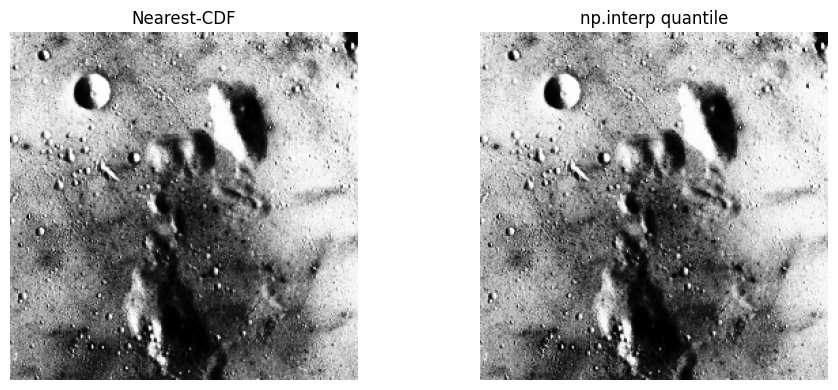

In [40]:
# Advance 1
def hist_matching_nearest(source, reference):
    matched, lut, cs, ct = histogram_matching(source, reference)
    return matched, lut

def hist_matching_interp(source, reference):
    N_s, N_r = source.size, reference.size
    hs = np.bincount(source.flatten(), minlength=256)
    ht = np.bincount(reference.flatten(), minlength=256)
    cs = np.cumsum(hs) / N_s
    ct = np.cumsum(ht) / N_r
    # np.interp trên quantile: với mỗi CDF_S(r), nội suy tuyến tính ra z tương ứng trên đường CDF_T
    lut = np.interp(cs, ct, np.arange(256)).astype(np.uint8)
    matched = lut[source]
    return matched, lut

matched_nearest, lut_nearest = hist_matching_nearest(img, reference)
matched_interp, lut_interp = hist_matching_interp(img, reference)

diff_lut = np.abs(lut_nearest.astype(int) - lut_interp.astype(int))
diff_out = np.abs(matched_nearest.astype(int) - matched_interp.astype(int))
print("Max |LUT diff| nearest vs interp:", diff_lut.max())
print("Max |output diff| nearest vs interp:", diff_out.max())

h1, h2 = normalized_hist(matched_nearest), normalized_hist(matched_interp)
print("Histogram similarity (Correlation):", cv2.compareHist(h1, h2, cv2.HISTCMP_CORREL))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(matched_nearest, cmap='gray'); axes[0].set_title("Nearest-CDF"); axes[0].axis('off')
axes[1].imshow(matched_interp, cmap='gray'); axes[1].set_title("np.interp quantile"); axes[1].axis('off')
plt.tight_layout(); plt.show()

In [41]:
# advance 2
def color_match_luminance(source_bgr, reference_bgr, space='YCrCb'):
    if space == 'YCrCb':
        src = cv2.cvtColor(source_bgr, cv2.COLOR_BGR2YCrCb)
        ref = cv2.cvtColor(reference_bgr, cv2.COLOR_BGR2YCrCb)
        ch = 0  # kênh Y
    else:  # LAB
        src = cv2.cvtColor(source_bgr, cv2.COLOR_BGR2LAB)
        ref = cv2.cvtColor(reference_bgr, cv2.COLOR_BGR2LAB)
        ch = 0  # kênh L

    matched_ch, _, _, _ = histogram_matching(src[:, :, ch], ref[:, :, ch])
    out = src.copy()
    out[:, :, ch] = matched_ch

    out_bgr = cv2.cvtColor(out, cv2.COLOR_YCrCb2BGR) if space == 'YCrCb' else cv2.cvtColor(out, cv2.COLOR_LAB2BGR)
    return out_bgr

def color_match_per_channel(source_bgr, reference_bgr):
    out = np.zeros_like(source_bgr)
    for c in range(3):
        out[:, :, c], _, _, _ = histogram_matching(source_bgr[:, :, c], reference_bgr[:, :, c])
    return out

# Ví dụ dùng ảnh màu (đọc lại có màu)
img_color = cv2.imread("image.jpg", cv2.IMREAD_COLOR)
ref_color = img_color  # thay bằng ảnh reference màu thật nếu có

luminance_matched = color_match_luminance(img_color, ref_color, space='YCrCb')
perchannel_matched = color_match_per_channel(img_color, ref_color)

# Phân tích color shift: so trung bình từng kênh BGR trước/sau
for name, im in [("Original", img_color), ("Luminance-match", luminance_matched), ("Per-channel", perchannel_matched)]:
    means = im.reshape(-1, 3).mean(axis=0)
    print(f"{name}: mean B={means[0]:.1f}, G={means[1]:.1f}, R={means[2]:.1f}")

Original: mean B=112.2, G=112.2, R=112.2
Luminance-match: mean B=112.2, G=112.2, R=112.2
Per-channel: mean B=112.2, G=112.2, R=112.2


In [42]:
# advance 3
def ahe_sliding_window(gray, win_size=31):
    H, W = gray.shape
    r = win_size // 2
    padded = cv2.copyMakeBorder(gray, r, r, r, r, cv2.BORDER_REFLECT)
    out = np.zeros_like(gray)

    for y in range(H):
        for x in range(W):
            win = padded[y:y+win_size, x:x+win_size]
            hist = np.bincount(win.flatten(), minlength=256)
            cdf = np.cumsum(hist)
            pixel_val = gray[y, x]
            out[y, x] = np.clip(round(cdf[pixel_val] / win.size * 255), 0, 255)
    return out

# So sánh độ chính xác & chi phí tính toán với AHE-tile (chỉ chạy ảnh nhỏ vì rất chậm)
small_img = cv2.resize(img, (64, 64))
import time

t0 = time.time()
ahe_win = ahe_sliding_window(small_img, win_size=15)
t_win = time.time() - t0

t0 = time.time()
ahe_tile = ahe_tiles_demo(small_img, grid=(8,8))
t_tile = time.time() - t0

print(f"Sliding window: {t_win:.3f}s | Tile-based: {t_tile:.3f}s")
diff_ahe = np.abs(ahe_win.astype(int) - ahe_tile.astype(int))
print("Max diff sliding vs tile:", diff_ahe.max())

Sliding window: 0.099s | Tile-based: 0.003s
Max diff sliding vs tile: 161


In [43]:
# advance 4
def make_low_contrast(gray):
    return (gray.astype(np.float64) * 0.3 + 100).clip(0,255).astype(np.uint8)

def make_uneven_illum(gray):
    H, W = gray.shape
    gradient = np.tile(np.linspace(-60, 60, W), (H, 1))
    return np.clip(gray.astype(np.float64) + gradient, 0, 255).astype(np.uint8)

def make_noisy(gray):
    noise = np.random.normal(0, 15, gray.shape)
    return np.clip(gray.astype(np.float64) + noise, 0, 255).astype(np.uint8)

test_groups = {
    "Low contrast": make_low_contrast(img),
    "Uneven illumination": make_uneven_illum(img),
    "Noisy": make_noisy(img)
}

rows = []
for group_name, test_img in test_groups.items():
    he_out, _ = he_numpy(test_img)
    ahe_out = ahe_tiles_demo(test_img, grid=(8,8))
    for method_name, out_im in [("HE", he_out), ("AHE", ahe_out)]:
        h_ref = normalized_hist(test_img)
        h_out = normalized_hist(out_im)
        rows.append({
            "Nhóm ảnh": group_name,
            "Phương pháp": method_name,
            "std sau": round(out_im.std(), 2),
            "Correlation": round(cv2.compareHist(h_out, h_ref, cv2.HISTCMP_CORREL), 4),
            "Bhattacharyya": round(cv2.compareHist(h_out, h_ref, cv2.HISTCMP_BHATTACHARYYA), 4)
        })

df_robust = pd.DataFrame(rows)
print(df_robust)

              Nhóm ảnh Phương pháp  std sau  Correlation  Bhattacharyya
0         Low contrast          HE    73.32       0.3554         0.8657
1         Low contrast         AHE    74.83       0.0155         0.8975
2  Uneven illumination          HE    73.50       0.0059         0.6746
3  Uneven illumination         AHE    73.75      -0.0235         0.5016
4                Noisy          HE    73.74      -0.0019         0.8444
5                Noisy         AHE    73.73      -0.0106         0.6000


# Challenge

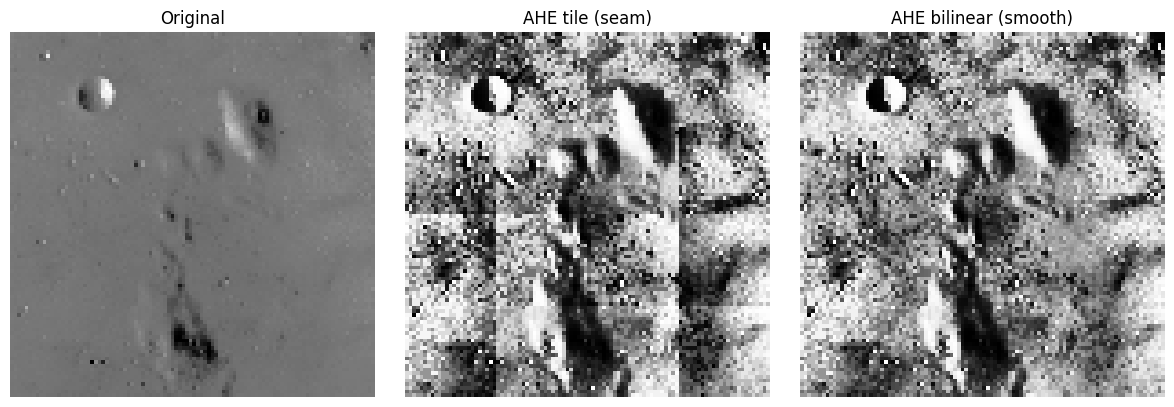

In [44]:
# Challenge 1
def ahe_bilinear(gray, grid=(8,8)):
    H, W = gray.shape
    gy, gx = grid
    y_edges = np.linspace(0, H, gy + 1, dtype=int)
    x_edges = np.linspace(0, W, gx + 1, dtype=int)

    # Tâm mỗi tile
    y_centers = [(y_edges[i] + y_edges[i+1]) / 2 for i in range(gy)]
    x_centers = [(x_edges[j] + x_edges[j+1]) / 2 for j in range(gx)]

    # LUT riêng cho từng tile
    luts = np.zeros((gy, gx, 256), dtype=np.uint8)
    for i in range(gy):
        for j in range(gx):
            y0, y1 = y_edges[i], y_edges[i+1]
            x0, x1 = x_edges[j], x_edges[j+1]
            tile = gray[y0:y1, x0:x1]
            _, lut = he_numpy(tile)
            luts[i, j] = lut

    out = np.zeros_like(gray, dtype=np.float64)
    for y in range(H):
        # tìm 2 tile row lân cận theo y_centers
        i1 = np.searchsorted(y_centers, y) - 1
        i1 = np.clip(i1, 0, gy - 2) if gy > 1 else 0
        i2 = min(i1 + 1, gy - 1)
        if gy == 1:
            wy = 0.0
        else:
            wy = (y - y_centers[i1]) / (y_centers[i2] - y_centers[i1] + 1e-9)
            wy = np.clip(wy, 0, 1)

        for x in range(W):
            j1 = np.searchsorted(x_centers, x) - 1
            j1 = np.clip(j1, 0, gx - 2) if gx > 1 else 0
            j2 = min(j1 + 1, gx - 1)
            if gx == 1:
                wx = 0.0
            else:
                wx = (x - x_centers[j1]) / (x_centers[j2] - x_centers[j1] + 1e-9)
                wx = np.clip(wx, 0, 1)

            v = gray[y, x]
            # nội suy song tuyến giữa 4 LUT lân cận
            top = (1-wx) * luts[i1, j1, v] + wx * luts[i1, j2, v]
            bot = (1-wx) * luts[i2, j1, v] + wx * luts[i2, j2, v]
            out[y, x] = (1-wy) * top + wy * bot

    return np.clip(out, 0, 255).astype(np.uint8)

# Chạy trên ảnh nhỏ (thuật toán vòng lặp thuần Python nên chậm với ảnh lớn)
small_test = cv2.resize(img, (100, 100))
ahe_bilin = ahe_bilinear(small_test, grid=(4,4))
ahe_notile = ahe_tiles_demo(small_test, grid=(4,4))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(small_test, cmap='gray'); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(ahe_notile, cmap='gray'); axes[1].set_title("AHE tile (seam)"); axes[1].axis('off')
axes[2].imshow(ahe_bilin, cmap='gray'); axes[2].set_title("AHE bilinear (smooth)"); axes[2].axis('off')
plt.tight_layout(); plt.show()


In [45]:
# Challenge 2
def choose_best_reference(source, reference_list, metric='bhattacharyya'):
    h_src = normalized_hist(source)
    scores = []
    for idx, ref in enumerate(reference_list):
        h_ref = normalized_hist(ref)
        if metric == 'bhattacharyya':
            score = cv2.compareHist(h_src, h_ref, cv2.HISTCMP_BHATTACHARYYA)  # nhỏ hơn = tốt hơn
        else:
            score = -cv2.compareHist(h_src, h_ref, cv2.HISTCMP_CORREL)  # âm để nhỏ hơn = tốt hơn
        scores.append(score)
    best_idx = int(np.argmin(scores))
    return best_idx, scores

reference_candidates = [he_manual, ahe_tiles_demo(img, grid=(8,8)), make_uneven_illum(img)]
best_idx, scores = choose_best_reference(img, reference_candidates, metric='bhattacharyya')
print("Điểm Bhattacharyya từng reference:", scores)
print("Reference phù hợp nhất: index", best_idx)

best_matched, _, _, _ = histogram_matching(img, reference_candidates[best_idx])

Điểm Bhattacharyya từng reference: [0.9253199268957811, 0.7733027033285377, 0.6340945206943047]
Reference phù hợp nhất: index 2


In [46]:
# Challenge 3
def he_preserve_brightness(gray, max_mean_shift=5.0):
    mean_orig = gray.mean()
    enhanced, _ = he_numpy(gray)
    mean_new = enhanced.mean()

    # Trộn (blend) ảnh gốc và ảnh HE để giữ mean trong ngưỡng cho phép
    alpha = 1.0
    result = enhanced.copy()
    while abs(result.mean() - mean_orig) > max_mean_shift and alpha > 0:
        alpha -= 0.05
        result = np.clip(alpha * enhanced.astype(np.float64) + (1 - alpha) * gray.astype(np.float64), 0, 255).astype(np.uint8)

    return result, alpha

preserved, alpha_used = he_preserve_brightness(img, max_mean_shift=5.0)
print(f"Mean gốc: {img.mean():.2f} | Mean HE thường: {he_manual.mean():.2f} | Mean preserved: {preserved.mean():.2f} (alpha={alpha_used:.2f})")

Mean gốc: 112.17 | Mean HE thường: 133.76 | Mean preserved: 117.05 (alpha=0.25)


  method                             params    mean    std  correlation  \
0     HE                   {'method': 'HE'}  133.76  74.01       1.0000   
1     HM                   {'method': 'HM'}  133.74  74.03       0.9998   
3    AHE  {'method': 'AHE', 'grid': (8, 8)}  140.00  74.36      -0.0165   
2    AHE  {'method': 'AHE', 'grid': (4, 4)}  137.13  74.32      -0.0013   

   bhattacharyya  
0         0.0000  
1         0.0277  
3         0.8057  
2         0.8192  


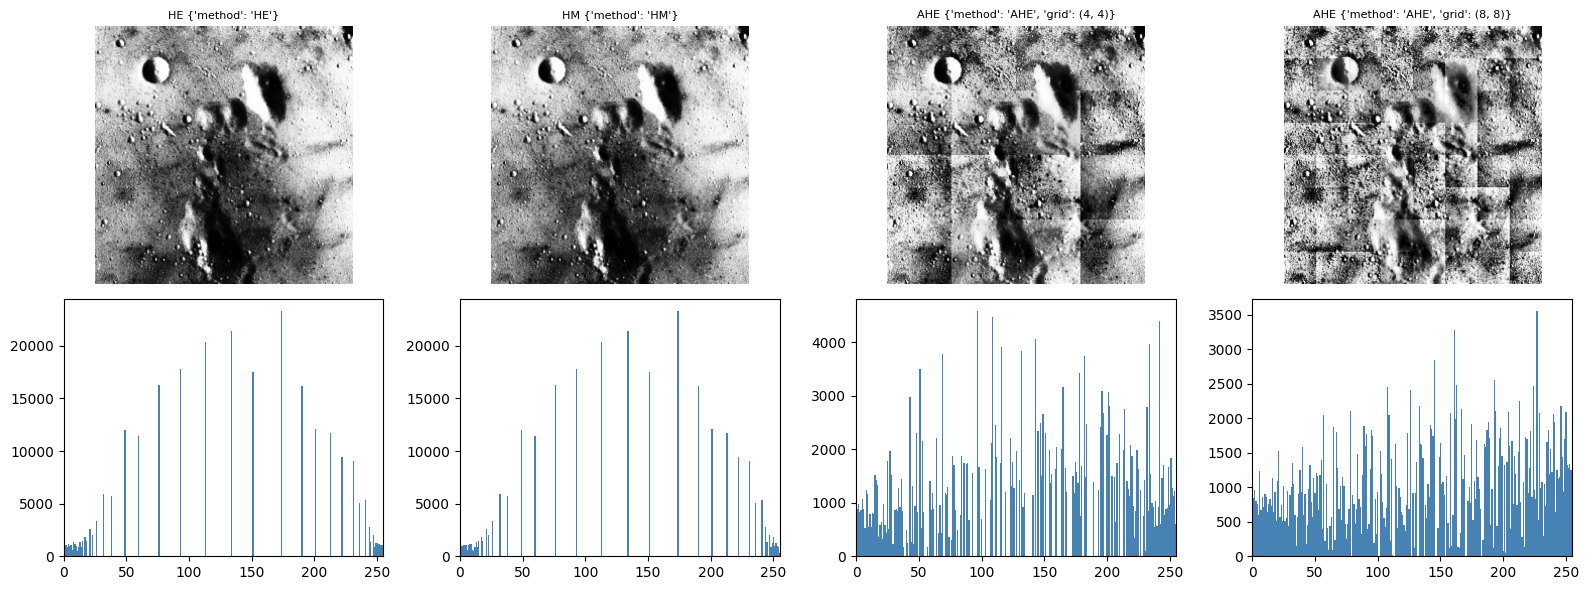

In [47]:
# Challenge 4
def run_experiment(gray, reference, configs):
    results_log = []
    for cfg in configs:
        method = cfg["method"]
        if method == "HE":
            out, _ = he_numpy(gray)
        elif method == "HM":
            out, _, _, _ = histogram_matching(gray, reference)
        elif method == "AHE":
            out = ahe_tiles_demo(gray, grid=cfg["grid"])
        else:
            continue

        h_ref = normalized_hist(reference)
        h_out = normalized_hist(out)
        results_log.append({
            "method": method,
            "params": str(cfg),
            "mean": round(out.mean(), 2),
            "std": round(out.std(), 2),
            "correlation": round(cv2.compareHist(h_out, h_ref, cv2.HISTCMP_CORREL), 4),
            "bhattacharyya": round(cv2.compareHist(h_out, h_ref, cv2.HISTCMP_BHATTACHARYYA), 4),
            "image": out
        })
    return results_log

configs = [
    {"method": "HE"},
    {"method": "HM"},
    {"method": "AHE", "grid": (4,4)},
    {"method": "AHE", "grid": (8,8)},
]

exp_results = run_experiment(img, reference, configs)
df_exp = pd.DataFrame([{k:v for k,v in r.items() if k != "image"} for r in exp_results])
df_exp_ranked = df_exp.sort_values("bhattacharyya")
print(df_exp_ranked)

# Xuất ảnh + histogram tự động cho từng cấu hình
fig, axes = plt.subplots(2, len(exp_results), figsize=(4*len(exp_results), 6))
for col, r in enumerate(exp_results):
    axes[0, col].imshow(r["image"], cmap='gray', vmin=0, vmax=255)
    axes[0, col].set_title(f"{r['method']} {r['params']}", fontsize=8)
    axes[0, col].axis('off')

    h = cv2.calcHist([r["image"]], [0], None, [256], [0,256]).flatten()
    axes[1, col].bar(np.arange(256), h, width=1, color='steelblue')
    axes[1, col].set_xlim(0, 255)

plt.tight_layout()
plt.show()

# 10 câu hỏi bắt buộc

1. Histogram khác PDF và CDF như thế nào?

- Histogram là số đếm (đếm số pixel) ứng với mỗi mức xám — giá trị nguyên, phụ thuộc kích thước ảnh. PDF là histogram đã chuẩn hoá theo tổng số pixel (PDF = hist/N), cho ra tần suất xuất hiện tương đối, tổng bằng 1. CDF là tổng cộng dồn của PDF từ mức 0 đến mức hiện tại, thể hiện tỉ lệ pixel có giá trị ≤ mức đó, luôn tăng từ 0 đến 1.

2. Vì sao histogram không lưu thông tin vị trí pixel?
- Vì histogram chỉ đếm tần suất xuất hiện của từng giá trị mức xám trên toàn ảnh, không quan tâm pixel đó nằm ở toạ độ nào. Do đó nhiều ảnh có bố cục không gian hoàn toàn khác nhau (hoán vị pixel) vẫn có thể cho ra cùng một histogram.

3. HE sử dụng CDF để tạo LUT như thế nào?
- HE ánh xạ mỗi mức xám đầu vào r sang mức xám đầu ra s theo công thức s = round((L-1) × CDF(r)). Vì CDF là hàm không giảm và trải từ 0 đến 1, phép nhân với (L-1) sẽ "kéo giãn" các mức xám sao cho phân bố tích luỹ mới gần tuyến tính hơn — nơi CDF tăng nhanh (nhiều pixel) thì khoảng cách s tương ứng bị giãn rộng, nơi CDF tăng chậm (ít pixel) thì các mức r bị nén lại gần nhau trong LUT.

4. Vì sao histogram sau HE không nhất thiết phẳng hoàn toàn?
- Vì phép biến đổi hoạt động trên tập giá trị mức xám rời rạc, nên khi làm tròn (round), nhiều mức input khác nhau có thể bị ánh xạ trùng vào cùng một mức output, còn có mức output khác lại không có pixel nào ánh xạ tới. Kết quả là histogram sau HE chỉ xấp xỉ đều hơn (được kéo trải rộng), chứ không phải là một đường phẳng tuyệt đối như lý thuyết liên tục.

5. Vai trò của CDF_min trong HE 8-bit là gì?
- CDF_min (giá trị tích luỹ khác 0 nhỏ nhất) dùng để chuẩn hoá công thức (cdf_count - cdf_min)/(N - cdf_min) × 255, đảm bảo mức xám nhỏ nhất thực sự xuất hiện trong ảnh luôn được ánh xạ chính xác về 0 (đầu dải động), thay vì lệch đi một khoảng do phần "cdf_min" bị tính dư vào công thức đơn giản 255×CDF. Nhờ đó LUT tận dụng trọn vẹn dải [0,255] ứng với đúng dải giá trị thực tế có trong ảnh.

6. Histogram Matching khác HE về mục tiêu và dữ liệu đầu vào như thế nào?
- HE có mục tiêu cố định là làm CDF đầu ra xấp xỉ phân bố đều (tuyến tính), chỉ cần ảnh nguồn làm đầu vào. Histogram Matching (HM) có mục tiêu linh hoạt hơn: biến đổi CDF của ảnh nguồn sao cho khớp với CDF của một ảnh Reference bất kỳ do người dùng chọn, nên đầu vào cần cả ảnh Source lẫn ảnh Reference — kết quả phụ thuộc trực tiếp vào đặc điểm phân bố của Reference chứ không cố định về một dạng phân bố chuẩn.

7. Vì sao khi matching phải tìm z bằng khoảng cách CDF thay vì ghép trực tiếp từng bin?
- Vì CDF của Source và Reference thường không có giá trị trùng khớp tuyệt đối tại cùng một mức xám (do hai ảnh có phân bố khác nhau, dữ liệu rời rạc). Nếu ghép trực tiếp theo chỉ số bin sẽ không đảm bảo tính chất "cùng phân vị tích luỹ" giữa hai ảnh. Việc tìm z sao cho |CDF_T(z) - CDF_S(r)| nhỏ nhất đảm bảo mức xám z được chọn ở Reference có cùng vị trí phân vị (percentile) với mức xám r ở Source — đúng bản chất mục tiêu của histogram matching.

8. Tại sao AHE phù hợp với illumination không đồng đều nhưng dễ khuếch đại noise?
- AHE chia ảnh thành nhiều vùng nhỏ (tile) và cân bằng histogram riêng cho từng vùng, nên có thể thích nghi với độ sáng/tương phản khác nhau ở từng khu vực cục bộ của ảnh — phù hợp khi illumination không đồng đều trên toàn ảnh. Tuy nhiên, chính vì xử lý cục bộ trên vùng nhỏ, nếu tile đó gần như đồng nhất (ít pixel, dải giá trị hẹp) thì CDF trong tile rất dốc, khiến những sai khác nhỏ do nhiễu bị khuếch đại mạnh thành chênh lệch lớn sau khi equalize (minh hoạ rõ ở Bài 8).

9. Tại sao ghép các tile equalize độc lập tạo seam?
- Vì mỗi tile có LUT (bảng ánh xạ) riêng, được tính hoàn toàn độc lập dựa trên histogram cục bộ của chính tile đó, không liên quan gì đến các tile lân cận. Hai pixel có giá trị gốc gần giống nhau nhưng nằm ở hai tile khác nhau (sát biên) có thể bị ánh xạ theo hai LUT khác hẳn nhau, gây ra bước nhảy giá trị đột ngột đúng tại đường ranh giới tile — tạo thành artifact dạng lưới (seam) nhìn thấy được.

10. Vì sao không nên đánh giá enhancement chỉ bằng cảm quan?
- Vì đánh giá bằng mắt mang tính chủ quan, phụ thuộc vào điều kiện hiển thị (màn hình, ánh sáng phòng) và dễ bị đánh lừa bởi cảm giác "nhìn rõ hơn" trong khi thực chất ảnh đã bị mất thông tin (bão hoà, cắt xén, over-enhancement) hoặc bị khuếch đại nhiễu/artifact. Cần dùng thêm các chỉ số định lượng khách quan (mean, std, dynamic range, các metric so sánh histogram như Correlation, Chi-square, Intersection, Bhattacharyya) để đánh giá đầy đủ, nhất quán và có thể tái lập được giữa các phương pháp và các ảnh khác nhau.